In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Standard keller-segel

All bacteria produce chemical.

In [ ]:
function simulate_OU(k, D, dt, T, r0)
    nsteps = Int(T/dt)
    r = zeros(nsteps)
    r[1] = r0

    for i in 2:nsteps
        ξ = randn()
        r[i] = r[i-1] - k * r[i-1] * dt + sqrt(2 * D * dt) * ξ

        # optional: avoid negative distance
        if r[i] < 0
            r[i] = 0.0
        end
    end

    return r
end

In [2]:
function meshgrid(x, y)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

meshgrid (generic function with 1 method)

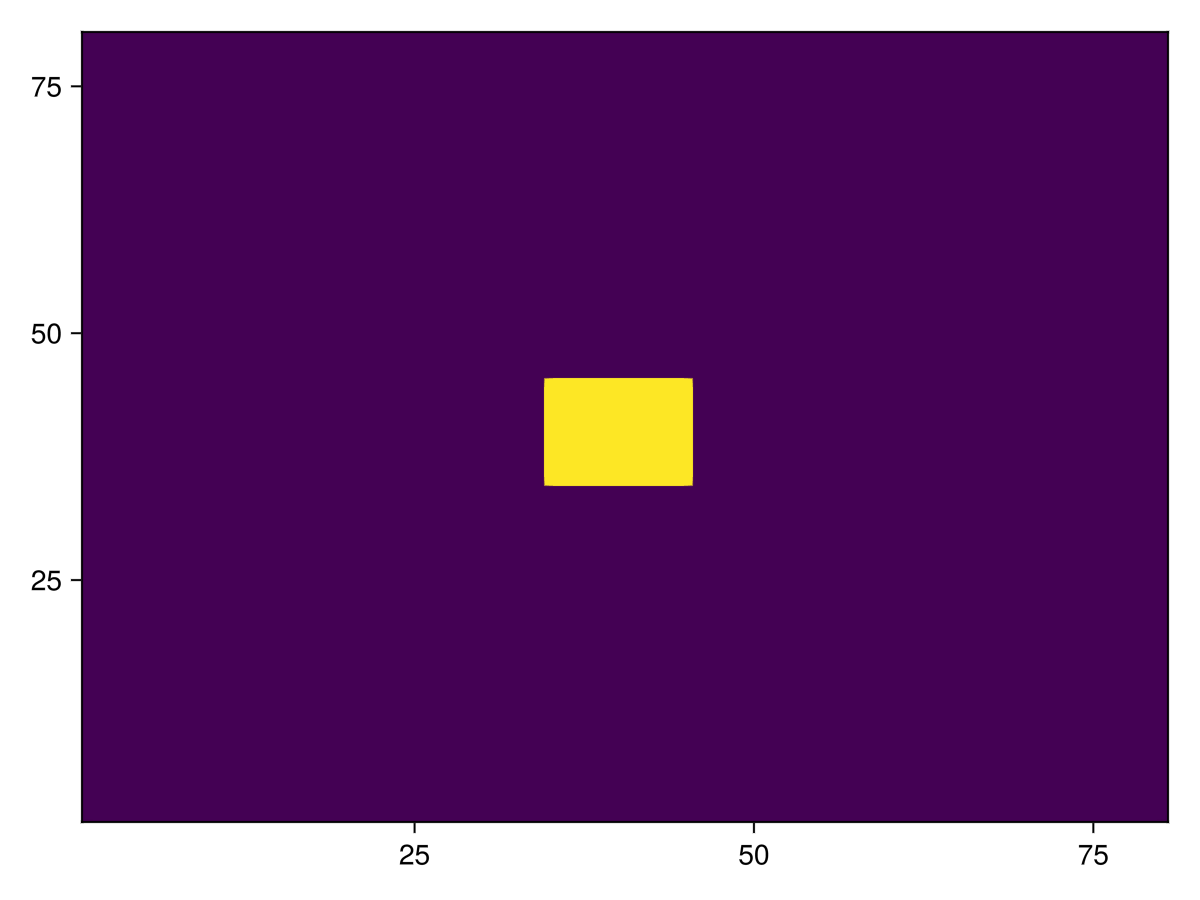

❌ NaN exploded at step 321
Done


In [81]:
using GLMakie

# -----------------------------
# Grid
# -----------------------------
Nx, Ny = 80, 80
dx = 1.0

# parameters (IMPORTANT: small dt!)
Dρ = 0.1      # cell diffusion
Dc = 1.0      # chemical diffusion
χ  = 2.0      # chemotaxis strength

dt = 0.01
steps = 2000

# -----------------------------
# Initial conditions
# -----------------------------
ρ = zeros(Nx, Ny)
c = zeros(Nx, Ny)

# small Gaussian bump
for i in 35:45, j in 35:45
    ρ[i, j] = 1.0
end

# -----------------------------
# helpers
# -----------------------------
function laplacian(A, i, j)
    return A[i+1,j] + A[i-1,j] + A[i,j+1] + A[i,j-1] - 4A[i,j]
end

function clamp!(A)
    @inbounds for i in eachindex(A)
        A[i] = max(A[i], 0.0)
    end
end

# -----------------------------
# Makie setup
# -----------------------------
fig = Figure()
ax = Axis(fig[1,1])

ρ_obs = Observable(ρ)
heat = heatmap!(ax, ρ_obs, colormap=:viridis)

display(fig)

# -----------------------------
# time loop
# -----------------------------
for n in 1:steps

    ρnew = copy(ρ)
    cnew = copy(c)

    @inbounds for i in 2:Nx-1, j in 2:Ny-1

        # Laplacians
        Δρ = laplacian(ρ, i, j)
        Δc = laplacian(c, i, j)

        # gradients of c (central differences)
        ∂cx = (c[i+1,j] - c[i-1,j]) / (2dx)
        ∂cy = (c[i,j+1] - c[i,j-1]) / (2dx)

        # Keller-Segel equations
        ρnew[i,j] = ρ[i,j] +
            dt * (Dρ * Δρ - χ * (ρ[i,j]*(∂cx + ∂cy)))

        cnew[i,j] = c[i,j] +
            dt * (Dc * Δc + ρ[i,j])
    end

    ρ .= ρnew
    c .= cnew

    clamp!(ρ)

    # update plot every few steps
    if n % 10 == 0
        ρ_obs[] = ρ
        sleep(0.01)
    end

    # safety check (VERY IMPORTANT)
    if any(isnan.(ρ)) || any(isinf.(ρ))
        println("❌ NaN exploded at step $n")
        break
    end
end

println("Done")

In [89]:
using GLMakie

# -------------------------
# grid
# -------------------------
Nx, Ny = 80, 80
L = 10.0
dx = L / Nx
dy = L / Ny

# -------------------------
# parameters (STABLE regime)
# -------------------------
Dρ = 0.1      # cell diffusion
Dc = 1.0      # chemoattractant diffusion
χ  = 1.5      # chemotaxis strength (keep small!)
α  = 1.0      # production rate
β  = 1.0      # decay rate

dt = 0.001    # MUST be small for stability
steps = 5000
plot_every = 50

# -------------------------
# helper: periodic laplacian
# -------------------------
function laplacian(u)
    Nx, Ny = size(u)
    lap = similar(u)
    @inbounds for i in 1:Nx, j in 1:Ny
        ip = i == Nx ? 1 : i+1
        im = i == 1  ? Nx : i-1
        jp = j == Ny ? 1 : j+1
        jm = j == 1  ? Ny : j-1

        lap[i,j] = (
            u[ip,j] + u[im,j] + u[i,jp] + u[i,jm] - 4u[i,j]
        ) / dx^2
    end
    return lap
end

# -------------------------
# chemotaxis flux limiter (prevents blow-up)
# -------------------------
safe_grad(u) = clamp.(u, 0.0, 10.0)

# -------------------------
# initial conditions (positive!)
# -------------------------
ρ = 0.5 .+ 0.01 .* rand(Nx, Ny)
c = zeros(Nx, Ny)

# add a bump
ρ[Nx÷2-5:Nx÷2+5, Ny÷2-5:Ny÷2+5] .+= 1.0

# -------------------------
# GLMakie setup
# -------------------------
fig = Figure()
ax = Axis(fig[1,1], title="Keller–Segel (stable regularized)")
ρ_obs = Observable(ρ)

hm = heatmap!(ax, ρ_obs, colormap=:viridis)
Colorbar(fig[1,2], hm)

display(fig)

# -------------------------
# time loop
# -------------------------
for n in 1:steps

    # enforce positivity (CRITICAL)
    ρ .= max.(ρ, 1e-8)
    c .= max.(c, 1e-8)

    Δρ = laplacian(ρ)
    Δc = laplacian(c)

    # gradient of c (central diff)
    ∇cx = similar(c)
    ∇cy = similar(c)

    @inbounds for i in 2:Nx-1, j in 2:Ny-1
        ∇cx[i,j] = (c[i+1,j] - c[i-1,j]) / (2dx)
        ∇cy[i,j] = (c[i,j+1] - c[i,j-1]) / (2dy)
    end

    # chemotaxis term: divergence of (ρ ∇c)
    div_chi = similar(ρ)

    @inbounds for i in 2:Nx-1, j in 2:Ny-1
        div_chi[i,j] =
            (ρ[i+1,j]*∇cx[i+1,j] - ρ[i-1,j]*∇cx[i-1,j])/(2dx) +
            (ρ[i,j+1]*∇cy[i,j+1] - ρ[i,j-1]*∇cy[i,j-1])/(2dy)
    end

    # update equations (REGULARIZED Keller–Segel)
    ρ .+= dt * (Dρ * Δρ .- χ .* div_chi)
    c .+= dt * (Dc * Δc .+ α .* ρ .- β .* c)

    # clamp AGAIN to prevent runaway
    ρ .= clamp.(ρ, 1e-8, 10.0)
    c .= clamp.(c, 0.0, 10.0)

    # update plot
    if n % plot_every == 0
        ρ_obs[] = copy(ρ)   # ✅ THIS is the correct way
        yield()
    end
end

In [99]:
using GLMakie

# ----------------------------
# grid
# ----------------------------
Nx, Ny = 80, 80
dx = 1.0

# ----------------------------
# parameters
# ----------------------------
Dρ = 0.1
Dc = 1.0
α  = 1.0
β  = 1.0

dt = 0.001

# ----------------------------
# initial condition
# ----------------------------
ρ = 0.5 .+ 0.01 .* rand(Nx, Ny)
ρ[Nx÷2-5:Nx÷2+5, Ny÷2-5:Ny÷2+5] .+= 1.0
c = zeros(Nx, Ny)

# ----------------------------
# laplacian
# ----------------------------
function laplacian(u)
    Nx, Ny = size(u)
    out = similar(u)
    @inbounds for i in 2:Nx-1, j in 2:Ny-1
        out[i,j] =
            (u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1] - 4u[i,j]) / dx^2
    end
    return out
end

# ----------------------------
# GUI state
# ----------------------------
running = Observable(false)
χ = Observable(2.0)

# ----------------------------
# figure
# ----------------------------
fig = Figure(size = (700, 600))

ax = Axis(fig[1,1], title = "Interactive Keller–Segel")

ρ_obs = Observable(ρ)
hm = heatmap!(ax, ρ_obs, colormap=:viridis)

# ----------------------------
# controls
# ----------------------------
btn_start = Button(fig[2,2], label="Start/Pause")
btn_step  = Button(fig[3,2], label="Step")

slider_χ = Slider(fig[4,1], range=0.0:0.1:5.0, startvalue=2.0)
label_χ = Label(fig[4,2], "χ")

fig[5,1:2] = label_χ

# ----------------------------
# bindings
# ----------------------------
on(btn_start.clicks) do _
    running[] = !running[]
end

on(btn_step.clicks) do _
    running[] = false
    do_step!(ρ, c, χ[])
    copyto!(ρ_obs[], ρ)
    notify(ρ_obs)
end
on(slider_χ.value) do v
    χ[] = v
end

# ----------------------------
# one simulation step
# ----------------------------
function do_step!(ρ, c, χval)

    ρ .= max.(ρ, 1e-8)
    c .= max.(c, 1e-8)

    Δρ = laplacian(ρ)
    Δc = laplacian(c)

    # gradients
    ∇cx = (circshift(c,(-1,0)) .- circshift(c,(1,0))) ./ (2dx)
    ∇cy = (circshift(c,(0,-1)) .- circshift(c,(0,1))) ./ (2dx)

    div_chi = laplacian(c .* ρ)

    ρ .+= dt .* (Dρ .* Δρ .- χval .* div_chi)
    c .+= dt .* (Dc .* Δc .+ α .* ρ .- β .* c)

    # stability clamp
    ρ .= clamp.(ρ, 1e-8, 10.0)
    c .= clamp.(c, 0.0, 10.0)
end

# ----------------------------
# animation loop
# ----------------------------
@async begin
    while true
        if running[]
            do_step!(ρ, c, χ[])
            copyto!(ρ_obs[], ρ)
            notify(ρ_obs)
        end
        sleep(0.01)
    end
end

display(fig)

GLMakie.Screen(...)